In [1]:
import paddle
import numpy as np
import pandas as pd
from paddle import grad
from matplotlib import pyplot as plt

# Constants
Gr = 2000
T = 50
H_t = 100
L_t = 2000
W_t = 400
H_b = 100
L_b = 2000
W_b = 400
H_g = 200
L_g = 400
W_g = 400
E = 30000
μ = 0.2
q = 0.007
a = 16000
b = 16000
G = E / (2 * (1 + μ))

# Calculations
t = (H_t * W_t / Gr + T)
B_t = E * T / (1 - μ**2)
B_b = E * T / (1 - μ**2)
h = H_g + 2*t
D11 = D22 = (h+t)**2/2*B_t
D12 = μ * (h+t)**2/2*B_t
D33 = 0
Cx = Cy  = L_g * W_g / (Gr**2) * H_g * G
C=Cx*Cy
# Model parameters
in_channels = 2  # x and y coordinates
out_channels = 1  # output w value

model = paddle.nn.Sequential(
    paddle.nn.Linear(2, 32),
    paddle.nn.Tanh(),
    paddle.nn.Linear(32, 64),
    paddle.nn.Tanh(),
    paddle.nn.Linear(64, 32),
    paddle.nn.Tanh(),
    paddle.nn.Linear(32, 1)
)
opt = paddle.optimizer.Adam(5e-4, parameters=model.parameters())

def grad_with_order(y, x, k):
    # Compute the gradient of y with respect to x at order k.
    g = y
    for _ in range(k):
        g = grad(g, x, create_graph=True, retain_graph=True)[0]
    return g

def mse(pred, label):
    # Compute the mean squared error between the predicted and true values.
    return ((pred - label) ** 2).mean()



# Load data
df = pd.read_excel('C:/Users/Administrator/Desktop/PLATE16mm/XLL.xlsx')
features = df.iloc[:, :2].values.astype("float32")  # [N, 2]
targets = df.iloc[:, 2].values.astype("float32")    # [N,]

features_max = np.max(features, axis=0)  # [2,]
features_min = np.min(features, axis=0)  # [2,]
features_normalized = features/ (features_max - features_min ) 


w_max = np.max(targets , axis=0)  # [2,]
w_min = np.min(targets , axis=0) 
K=w_max-w_min 
w_normalized = targets / K# 归一化到[0,1]
w_true_large = paddle.to_tensor(w_normalized.reshape(-1, 1), stop_gradient=False)

x_large= paddle.to_tensor(features_normalized[:, 0:1], stop_gradient=False)
y_large = paddle.to_tensor(features_normalized[:, 1:2], stop_gradient=False)
tensor_input_large = paddle.concat([x_large, y_large], axis=1)
print(features)
df = pd.read_excel('C:/Users/Administrator/Desktop/PLATE16mm/BCL.xlsx')
features = df.iloc[:, :2].values.astype("float32")  # [N, 2]
targets = df.iloc[:, 2].values.astype("float32")    # [N,]
print(features)
features_max = np.max(features, axis=0)  # [2,]
features_min = np.min(features, axis=0)  # [2,]
features_normalized = features  / (features_max - features_min ) 


w_true_small = paddle.to_tensor(targets .reshape(-1, 1), stop_gradient=False)

x_small= paddle.to_tensor(features_normalized[:, 0:1], stop_gradient=False)
y_small = paddle.to_tensor(features_normalized[:, 1:2], stop_gradient=False)
tensor_input_small = paddle.concat([x_small, y_small], axis=1)

saved_thresholds = set()  # 
for i in range(10000):
    if i % 200 < 100:
       x, y = x_large, y_large
       tensor_input = tensor_input_large
       w_true = w_true_large 
    else:
       x, y = x_small, y_small
       tensor_input = tensor_input_small
       w_true = w_true_small
    output = model(tensor_input)
    φ = output
    
    # Compute derivatives with retain_graph=True
    dφ_dx = grad(φ, x, create_graph=True, retain_graph=True)[0]
    dφ_dy = grad(φ, y, create_graph=True, retain_graph=True)[0]
    
    d2φ_dx2 = grad(dφ_dx, x, create_graph=True, retain_graph=True)[0]
    d2φ_dy2 = grad(dφ_dy, y, create_graph=True, retain_graph=True)[0]
    
    d3φ_dx3 = grad(d2φ_dx2, x, create_graph=True, retain_graph=True)[0]
    d3φ_dy3 = grad(d2φ_dy2, y, create_graph=True, retain_graph=True)[0]
    
    d4φ_dx4 = grad(d3φ_dx3, x, create_graph=True, retain_graph=True)[0]
    d4φ_dy4 = grad(d3φ_dy3, y, create_graph=True, retain_graph=True)[0]
    d4φ_dx2dy2 = grad(d2φ_dx2, y, create_graph=True, retain_graph=True)[0]
    
    d5φ_dx5 = grad(d4φ_dx4, x, create_graph=True, retain_graph=True)[0]
    d5φ_dy5 = grad(d4φ_dy4, y, create_graph=True, retain_graph=True)[0]
    d5φ_dx3dy2 = grad(d3φ_dx3, y, create_graph=True, retain_graph=True)[0]
    d5φ_dx2dy3 = grad(d2φ_dx2, y, create_graph=True, retain_graph=True)[0]
    
    d6φ_dx6 = grad(d5φ_dx5, x, create_graph=True, retain_graph=True)[0]
    d6φ_dy6 = grad(d5φ_dy5, y, create_graph=True, retain_graph=True)[0]
    d6φ_dx4dy2 = grad(d4φ_dx4, y, create_graph=True, retain_graph=True)[0]
    d6φ_dx2dy4 = grad(d2φ_dx2, y, create_graph=True, retain_graph=True)[0]

    # Scale derivatives
    d2dx2_dim = d2φ_dx2 * (1 / a**2)
    d2dy2_dim = d2φ_dy2 * (1/ b**2)
    d4dx4_dim = d4φ_dx4 * (1 / a**4)
    d4dy4_dim = d4φ_dy4 * (1/ b**4)
    d4dx2dy2_dim = d4φ_dx2dy2 * (1 / (a**2 * b**2))
    d6dx6_dim = d6φ_dx6 * (1 / a**6)
    d6dy6_dim = d6φ_dy6 * (1/ b**6)
    d6dx4dy2_dim = d6φ_dx4dy2 * (1 / (a**4 * b**2))
    d6dy4dx2_dim = d6φ_dx2dy4 * (1 / (a**2 * b**4))
    
    # PDE terms
    term1 = ((-D11*D22 + D12**2 + 2*D12*D33)*Cx - Cy*D11*D33) /C* d6dx4dy2_dim
    term2 = (-Cx*D22*D33 - Cy*(D11*D22 - D12**2 - 2*D12*D33)) /C* d6dy4dx2_dim
    term3 = -Cx*D11*D33 /C* d6dx6_dim
    term4 = -Cy*D22*D33 /C* d6dy6_dim
    term5 = (2*D12 + 4*D33)*d4dx2dy2_dim
    term6  =D11* d4dx4_dim
    term7 = D22*d4dy4_dim
   
   

    w_term1 = (D11 * D22 - D12**2 - 2 * D12 * D33) / C * d4dx2dy2_dim
    w_term2 = (D11 * D33) / C * d4dx4_dim
    w_term3 = (D22 * D33) / C * d4dy4_dim
    w_term4 = -(D11 * Cy + D33 * Cx) / C * d2dx2_dim
    w_term5 = -(D22 * Cx + D33 * Cy) / C * d2dy2_dim

    left = (term1 + term2 + term3 + term4+term5+term6+ term7)
    w_pr = w_term1 + w_term2 + w_term3 + w_term4 + w_term5+φ
    w_pr=w_pr/K
    loss_pde = mse(left, q)
    loss_data = mse(w_pr, w_true)
    loss = 0.9*loss_data+0.1*loss_pde


    opt.clear_grad()
    loss.backward(retain_graph=True)
    opt.step()
    
    if i % 10 == 0:
        print(f"Loss at iter {i}: PDE={loss_pde.item():.3e}, Data={loss_data.item():.3e}, Total={loss.item():.3e}")

    
    # Save model at different thresholds
    if loss.item() < 0.05 and 0.05 not in saved_thresholds:
        paddle.save(model.state_dict(), f"model_loss_0.05.pdparams")
        print("Model saved at loss < 0.05")
        saved_thresholds.add(0.05)
    elif loss.item() < 0.1 and 0.1 not in saved_thresholds:
        paddle.save(model.state_dict(), f"model_loss_0.1.pdparams")
        print("Model saved at loss < 0.1")
        saved_thresholds.add(0.1)
    elif loss.item() < 0.5 and 0.5 not in saved_thresholds:
        paddle.save(model.state_dict(), f"model_loss_0.5.pdparams")
        print("Model saved at loss < 0.5")
        saved_thresholds.add(0.5)
print(w_pr)
print(w_true_large )

C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


[[ 3712.85   5903.37 ]
 [-3527.15   1583.37 ]
 [  792.852 -6176.63 ]
 ...
 [ -567.148  1343.37 ]
 [ 6632.85  -6176.63 ]
 [ 4152.85   5183.37 ]]
[[ 7912.85 -8016.63]
 [ 7832.85  8303.37]
 [-8407.15 -8096.63]
 ...
 [ 3612.85 -8096.63]
 [-8487.15 -3796.63]
 [ 5612.85 -8096.63]]
Loss at iter 0: PDE=4.900e-05, Data=2.586e-01, Total=2.328e-01
Model saved at loss < 0.5
Loss at iter 10: PDE=4.899e-05, Data=2.519e-01, Total=2.267e-01
Loss at iter 20: PDE=4.899e-05, Data=2.428e-01, Total=2.185e-01
Loss at iter 30: PDE=4.897e-05, Data=2.296e-01, Total=2.066e-01
Loss at iter 40: PDE=4.895e-05, Data=2.111e-01, Total=1.900e-01
Loss at iter 50: PDE=4.891e-05, Data=1.869e-01, Total=1.682e-01
Loss at iter 60: PDE=4.887e-05, Data=1.589e-01, Total=1.430e-01
Loss at iter 70: PDE=4.885e-05, Data=1.316e-01, Total=1.184e-01
Loss at iter 80: PDE=4.886e-05, Data=1.104e-01, Total=9.941e-02
Model saved at loss < 0.1
Loss at iter 90: PDE=4.889e-05, Data=9.789e-02, Total=8.810e-02
Loss at iter 100: PDE=4.892e-05, 

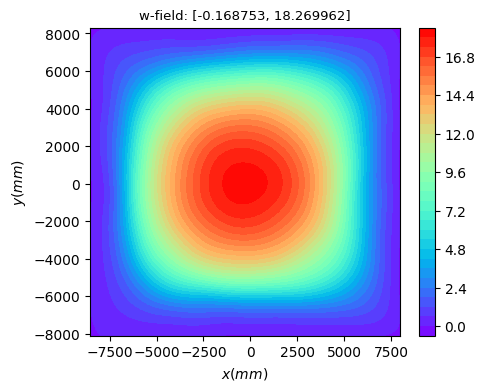

saved matplotlib to: ./result.jpg


In [4]:
paddle.save(model.state_dict(), f"finalB50G2000T200L400X100.pdparams")
model.eval()
cs = pd.read_excel('C:/Users/Administrator/Desktop/PLATE16mm/B50G2000T200L400X100.xlsx')
features = cs.iloc[:, :2].values.astype("float32") 

features_max = np.max(features, axis=0)  # [2,]
features_min = np.min(features, axis=0)  # [2,]
features_normalized = features  / (features_max - features_min ) 
x = paddle.to_tensor(features_normalized[:, 0:1], stop_gradient=False)  # [N, 1]
y = paddle.to_tensor(features_normalized[:, 1:2], stop_gradient=False)  # [N, 1]

inputs = paddle.concat([x, y], axis=1)  # [N, 2]
def xd(inputs):
    output = model(inputs )
    φ = output
    
    # Compute derivatives with retain_graph=TrueS
    dφ_dx = grad(φ, x, create_graph=True, retain_graph=True)[0]
    dφ_dy = grad(φ, y, create_graph=True, retain_graph=True)[0]
    
    d2φ_dx2 = grad(dφ_dx, x, create_graph=True, retain_graph=True)[0]
    d2φ_dy2 = grad(dφ_dy, y, create_graph=True, retain_graph=True)[0]
    
    d3φ_dx3 = grad(d2φ_dx2, x, create_graph=True, retain_graph=True)[0]
    d3φ_dy3 = grad(d2φ_dy2, y, create_graph=True, retain_graph=True)[0]
    
    d4φ_dx4 = grad(d3φ_dx3, x, create_graph=True, retain_graph=True)[0]
    d4φ_dy4 = grad(d3φ_dy3, y, create_graph=True, retain_graph=True)[0]
    d4φ_dx2dy2 = grad(d2φ_dx2, y, create_graph=True, retain_graph=True)[0]
    

    # Scale derivatives
    d2dx2_dim = d2φ_dx2 * (1 / a**2)
    d2dy2_dim = d2φ_dy2 * (1/ b**2)
    d4dx4_dim = d4φ_dx4 * (1 / a**4)
    d4dy4_dim = d4φ_dy4 * (1/ b**4)
    d4dx2dy2_dim = d4φ_dx2dy2 * (1 / (a**2 * b**2))

    
    w_term1 = (D11 * D22 - D12**2 - 2 * D12 * D33) / C * d4dx2dy2_dim
    w_term2 = (D11 * D33) / C * d4dx4_dim
    w_term3 = (D22 * D33) / C * d4dy4_dim
    w_term4 = -(D11 * Cy + D33 * Cx) / C * d2dx2_dim
    w_term5 = -(D22 * Cx + D33 * Cy) / C * d2dy2_dim
       
    w_pr = w_term1 + w_term2 + w_term3 + w_term4 + w_term5+φ
    w_pr= w_pr
    w_pr = w_pr.numpy()
    return   w_pr
x_plot = paddle.to_tensor(features[:, 0:1]).numpy().ravel()
y_plot= paddle.to_tensor(features[:, 1:2]).numpy().ravel()
w_pr=xd(inputs)
# Create plot
fig = plt.figure(100, figsize=(5, 4))
y_min = w_pr.min()
y_max = w_pr.max()
ax1 = plt.subplot(1, 1, 1)
contour = plt.tricontourf(x_plot, y_plot, w_pr[:, 0], levels=30, cmap="rainbow")
cb1 = plt.colorbar(contour)
plt.axis("equal")
plt.xlabel("$x (mm)$")
plt.ylabel("$y (mm)$")
plt.title(f"w-field: [{w_pr.min():.6f}, {w_pr.max():.6f}]", fontsize=9.5)
plt.show()
# Save figure
plt.savefig("./result.jpg", dpi=300, bbox_inches='tight')
plt.close()
print("saved matplotlib to: ./result.jpg")